In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the main dataset
game = pd.read_csv('../csv/game.csv')

# Getting a look at what I'm working with
print(game.shape)
print(game.dtypes)
game.head()

(65698, 55)
season_id                   int64
team_id_home                int64
team_abbreviation_home     object
team_name_home             object
game_id                     int64
game_date                  object
matchup_home               object
wl_home                    object
min                         int64
fgm_home                  float64
fga_home                  float64
fg_pct_home               float64
fg3m_home                 float64
fg3a_home                 float64
fg3_pct_home              float64
ftm_home                  float64
fta_home                  float64
ft_pct_home               float64
oreb_home                 float64
dreb_home                 float64
reb_home                  float64
ast_home                  float64
stl_home                  float64
blk_home                  float64
tov_home                  float64
pf_home                   float64
pts_home                  float64
plus_minus_home             int64
video_available_home        int64
te

,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,...,reb_away,ast_away,stl_away,blk_away,tov_away,pf_away,pts_away,plus_minus_away,video_available_away,season_type
0,21946,1610610035,HUS,Toronto Huskies,24600001,1946-11-01 00:00:00,HUS vs. NYK,L,0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,2,0,Regular Season
1,21946,1610610034,BOM,St. Louis Bombers,24600003,1946-11-02 00:00:00,BOM vs. PIT,W,0,20.0,...,NaN,NaN,NaN,NaN,NaN,25.0,51.0,-5,0,Regular Season
2,21946,1610610032,PRO,Providence Steamrollers,24600002,1946-11-02 00:00:00,PRO vs. BOS,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,53.0,-6,0,Regular Season
3,21946,1610610025,CHS,Chicago Stags,24600004,1946-11-02 00:00:00,CHS vs. NYK,W,0,21.0,...,NaN,NaN,NaN,NaN,NaN,22.0,47.0,-16,0,Regular Season
4,21946,1610610028,DEF,Detroit Falcons,24600005,1946-11-02 00:00:00,DEF vs. WAS,L,0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,50.0,17,0,Regular Season


In [31]:
# Focus on modern era and regular season only
# The 3-point line was introduced in 1979-1980, and early data is sparse
game['game_date'] = pd.to_datetime(game['game_date'])

modern = game[
    (game['game_date'].dt.year >= 1980) &
    (game['season_type'] == 'Regular Season')
].copy()

print(modern.shape)
print(modern['wl_home'].value_counts())
print(f"\nHome win percentage: {(modern['wl_home'] == 'W').mean():.3f}")

(47502, 55)
wl_home
W    28804
L    18698
Name: count, dtype: int64

Home win percentage: 0.606


## Cell 1 Explanation
### Filtering
The code above filtered to modern data and regular season only. We don't want pre-1980 data because it is missing too many stats and we don't want playoff games mixing into our analysis because:

1. Playoff teams are not a random sample. Only the top 16 teams make the playoffs. If you mix playoff and regular season data, you're no longer studying "what makes teams win" — you're studying "what happens when good teams play other good teams." That's a different question and it biases your findings. For example, defensive rating might look less predictive in the playoffs simply because every team there already plays good defense.

2. Playoff basketball is strategically different. Teams game-plan obsessively for specific opponents over a 7-game series. Coaches make major adjustments between games. Role players get targeted. This changes the statistical relationships in ways that don't reflect how winning works over an 82-game season, which is what we're trying to understand.

Later I will do this same analysis on only playoff data and see if the same factors that predict regular season games can predict playoff games. 

### Home Court Advantage
Across 47,502 regular season games since 1980, home teams win 60.6% of the time.
This aligns with well-documented home court advantage driven by crowd support, arena familiarity, and travel fatigue for visiting teams.

I wonder if there are any other factors that contribute. Other potential factors include referee familiarity, altitude differences, and timezone travel across conferences.

In [32]:
# Calculate point differential - the single best predictor of winning
modern['point_diff_home'] = modern['pts_home'] - modern['pts_away']

# Look at average stats for wins vs losses
win_stats = modern.groupby('wl_home')[['pts_home', 'fg_pct_home', 'fg3_pct_home', 'ft_pct_home', 'reb_home', 'ast_home', 'tov_home', 'stl_home', 'blk_home']].mean().round(3)

print(win_stats)
                                     

         pts_home  fg_pct_home  fg3_pct_home  ft_pct_home  reb_home  ast_home  \
wl_home                                                                         
L          97.939        0.437         0.307        0.745    41.689    21.849   
W         109.226        0.489         0.373        0.766    45.068    25.524   

         tov_home  stl_home  blk_home  
wl_home                                
L          15.085     7.343     4.775  
W          14.528     8.407     5.684  


## Home Court Advantage & Winning Stat Differentials
### Code Explanation
The code above does two things:
1. Adds a new column to our dataframe that has to do with point differential at home. Point differential is an important metric to track because teams that win close games a lot tend to regress the following season. Teams that win by a greater average margin tend to maintain that same streak of winning. This concept is call "pythagorean expectation" in sports analytics.

2. Splits the dataframe into two groups (wins and losses) and selects only the colums we care about from each group. Then we calculate the mean of each column so we get an average of the totals in said column. We then got a summary table.

### Biggest Drivers of Winning
The results showed that field goal percentage (48.9% in wins vs. 43.7% in losses), 3-point field goal percentage (37.3% in wins vs. 30.7% in losses), and rebound differential (45.068 vs. 41.689) were the biggest factors in separating winning teams and losing teams.

### Surprising Metrics
The stat that surprised me was the turnover counts. I figured that winning teams would have at least 3 more turnovers a game than the losing team, but they were only separated by ~0.5
Usually, you hear analysts saying turnovers lose games, but is that really the truth?

Another interesting thing about my results is the little difference between free throw percentage between winning and losing teams. This tells me that crowds don't influence free throws as much as I thought. This difference has probably grown closer over the years and that's something I might find out later.

Next, we'll visualize these relationships to identify which stats most strongly correlate with winning.

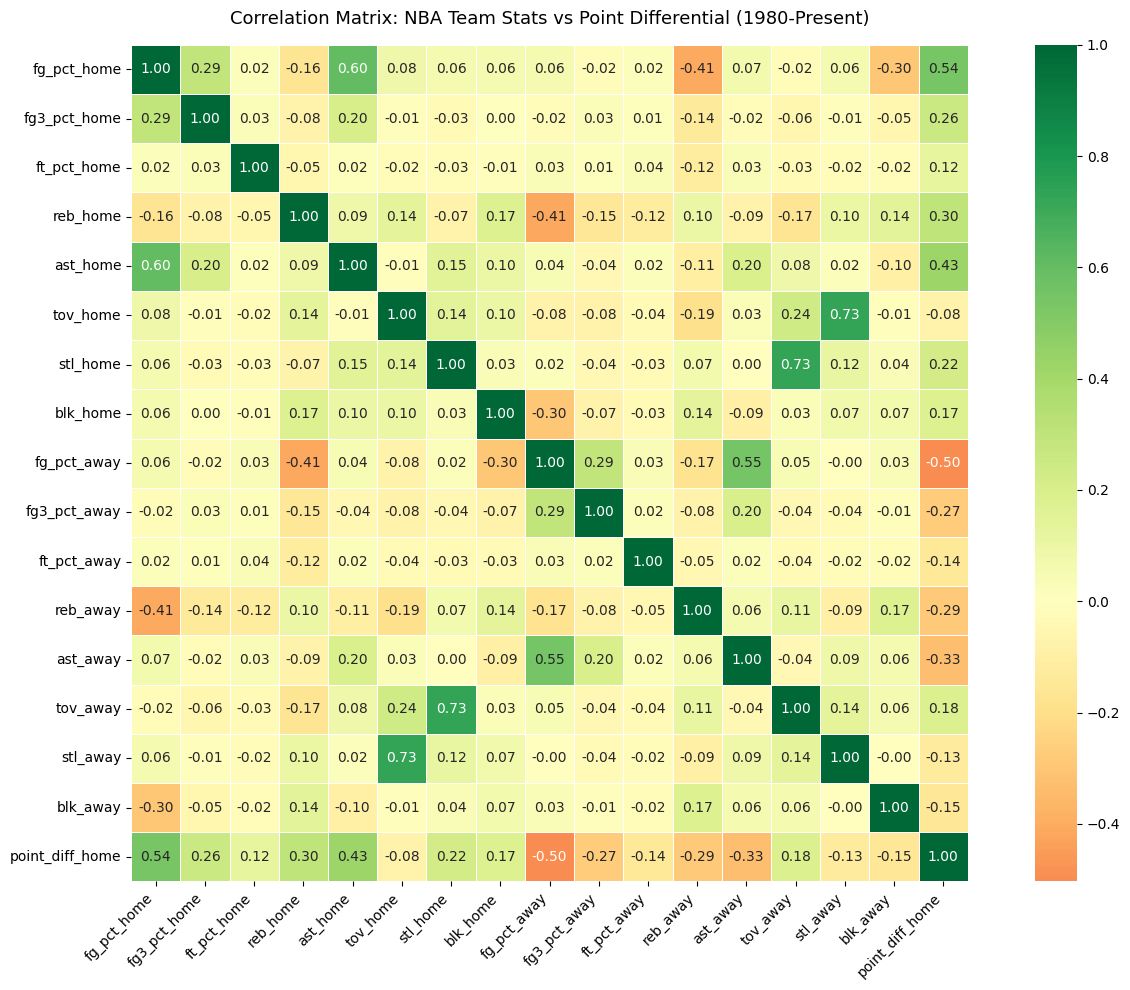

In [33]:
# Correlation heatmap of key stats vs point differential
stats_cols = ['fg_pct_home', 'fg3_pct_home', 'ft_pct_home', 'reb_home', 'ast_home', 
              'tov_home', 'stl_home', 'blk_home', 'fg_pct_away', 'fg3_pct_away', 
              'ft_pct_away', 'reb_away', 'ast_away', 'tov_away', 'stl_away', 'blk_away', 
              'point_diff_home']

correlation_matrix = modern[stats_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn', 
            center=0, 
            square=True, 
            linewidths=0.5)

plt.title("Correlation Matrix: NBA Team Stats vs Point Differential (1980-Present)",
          fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../visuals/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Heatmap Point Differential Home vs. Key Stats Analysis
### Code Explanation
In the code above I grouped all key stats together and compared them all vs. point differential. I wanted to see which stats were the key drivers of winning/losing at home. Because home teams win 60% of the time there has to be some statistical evidence backing it up. This is why I generated a heatmap.

### What's in the Chart?
The chart is a visual representation of a correlation matrix. The correlation matrix lives on a -1.0 to 1.0 scale and works like this: 
1. 1.0 = perfect positive relationship (when one goes up, the other always goes up)
2. 0.0 = no relationship at all
3. -1.0 = perfect negative relationship (when one goes up, the other always goes down)
So for example, if fg_pct_home and point_diff_home have a correlation of 0.65, that means home teams that shoot better tend to win by more.

### Top Findings
My top findings in this heatmap are in the last row. We are directly comparing point differential at home against every stat. In this row we found that fg_pct_home and ast_home were the biggest home drivers and that fg_pct_away was the strongest negative. This means that winning teams tend to have high field goal percentage and assists per game. Also, when a home team loses the heatmap shows that it is probably due to the away team's high field goal percentage. 

Earlier, I predicted turnovers would be a big driver of wins/losses, but this heatmap is another visual representation of the data that directly opposes that idea. Turnovers show a negligible correlation of -0.08 with point differential, suggesting their impact on winning margin is minimal compared to shooting efficiency. 

There is also a significant correlation between point_differential_home and reb_away (-0.41), suggesting that when the away team rebounds well, the home team shoots worse. This could mean that the home team can't get any high percentage second chances or that the away team is dominating the basketball, not allowing the home team to get into rhythm.

### Predictions and What's Next
Above, I said that good stats in assists and field goal percentage were the biggest signs of winning at home. My only thought about this is that the both directly affect each other. When you get a good pass in scoring position that tends to lead to higher make percentages. So, my prediction (and I'm planning on backing this up with data) is that assists lead to high field goal percentages.

Next, I'm going to build a visualization comparing wins vs losses across the key stats to make these findings more digestible.



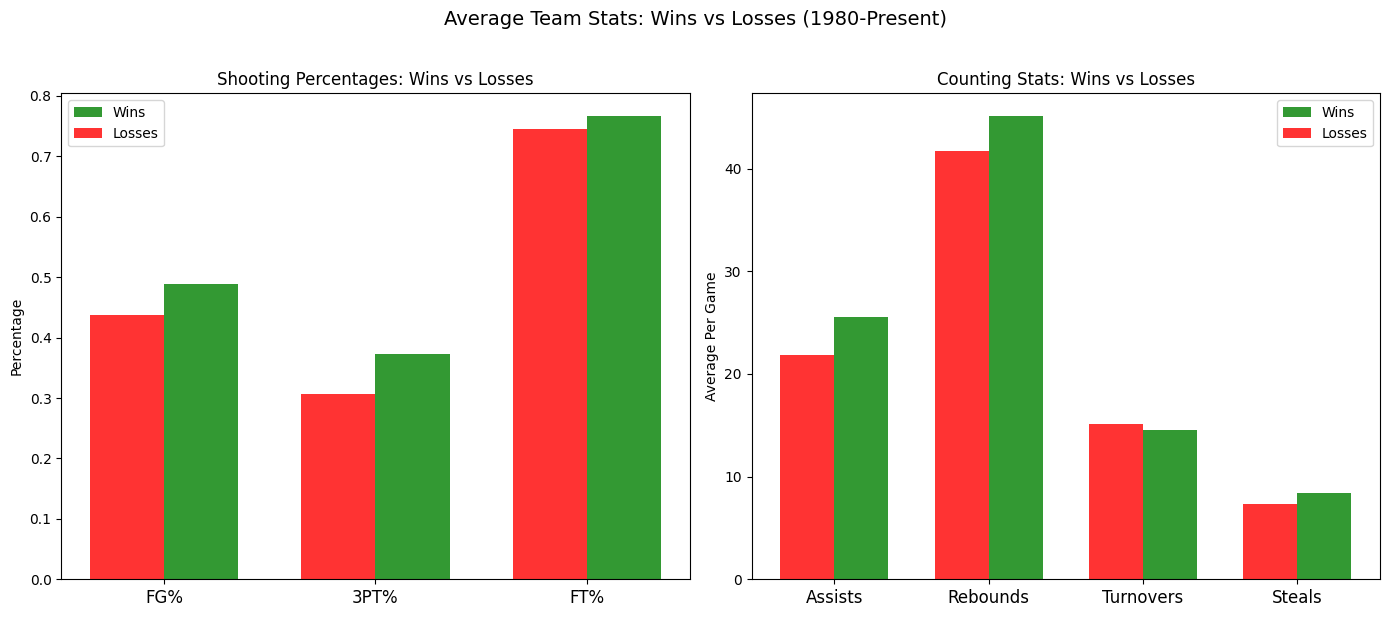

In [34]:
# Split into two charts to handle different scales
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Width of bars in both charts
width = 0.35

# Chart 1 - Shooting Percentages
pct_stats = ['fg_pct_home', 'fg3_pct_home', 'ft_pct_home']
pct_labels = ['FG%', '3PT%', 'FT%']
pct_wins = [win_stats.loc['W', col] for col in pct_stats]
pct_losses = [win_stats.loc['L', col] for col in pct_stats]

x1 = range(len(pct_stats))
ax1.bar([i + width/2 for i in x1], pct_wins, width, label='Wins', color='green', alpha=0.8)
ax1.bar([i - width/2 for i in x1], pct_losses, width, label='Losses', color='red', alpha=0.8)
ax1.set_xticks(list(x1))
ax1.set_xticklabels(pct_labels, fontsize=12)
ax1.set_title('Shooting Percentages: Wins vs Losses', fontsize=12)
ax1.set_ylabel('Percentage')
ax1.legend()

# Chart 2 - Counting Stats
count_stats = ['ast_home', 'reb_home', 'tov_home', 'stl_home']
count_labels = ['Assists', 'Rebounds', 'Turnovers', 'Steals']
count_wins = [win_stats.loc['W', col] for col in count_stats]
count_losses = [win_stats.loc['L', col] for col in count_stats]

x2 = range(len(count_stats))
ax2.bar([i + width/2 for i in x2], count_wins, width, label='Wins', color='green', alpha=0.8)
ax2.bar([i - width/2 for i in x2], count_losses, width, label='Losses', color='red', alpha=0.8)
ax2.set_xticks(list(x2))
ax2.set_xticklabels(count_labels, fontsize=12)
ax2.set_title('Counting Stats: Wins vs Losses', fontsize=12)
ax2.set_ylabel('Average Per Game')
ax2.legend()

plt.suptitle('Average Team Stats: Wins vs Losses (1980-Present)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../visuals/wins_vs_losses_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## Barchart Average Stats on Wins vs Losses Analysis
### Code Explanation
The code above creates two separate subplots comparing the average stats in wins versus losses. Originally, I had one big graph, but had to filter into two subplots because of different units/scales being used on the x-axis. The field goal/free throw percentages were getting overshadowed due the whole number stats (assists, rebounds, turnovers, and steals) being much larger numbers than that percentages (0.489, 0.437, etc.). Due to this I separated them into a graph with all the percentages and a graph with all the whole number stats. This kept the scale consistent throughout all key statistics. 

### Key Findings
1. FG% and 3PT% show big visible gaps, which is exactly what I concluded based off of the heatmap above. They are the biggest drivers of wins vs losses.
2. FT% is surprisingly close together, indicating they aren't a major factor in wins vs losses. This is surprising because you would think home teams would shoot better from the line and therefore gain more points.
3. The assists gap is the biggest proportional gap in the counting stats chart, which also agrees with what I found from the heatmap.
4. Rebounds also have a sizable gap, though not as big as assists, indicating they play a part in determining a win or a loss.

### Heatmap Connections and What's Next
These bar charts directly support my findings from the heatmap above. Further cementing my earlier hypotheses.

Next, we will test how closely assists relate to a high field goal percentage. I mentioned testing this earlier and feel it will present meaningful findings.



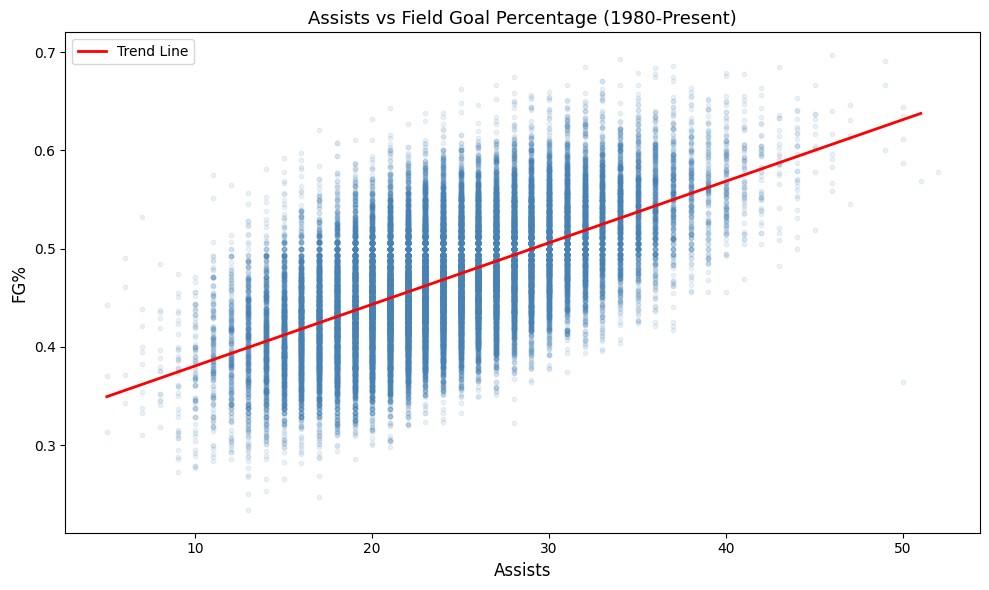

Correlation between assists and FG%: 0.603


In [35]:
# Testing the relationship between assists and FG%
clean = modern[['ast_home', 'fg_pct_home']].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(clean['ast_home'], clean['fg_pct_home'], 
            alpha=0.1, color='steelblue', s=10)

# Add a trend line
z = np.polyfit(clean['ast_home'], clean['fg_pct_home'], 1)
p = np.poly1d(z)
x_line = range(int(clean['ast_home'].min()), 
               int(clean['ast_home'].max()))
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend Line')

plt.xlabel('Assists', fontsize=12)
plt.ylabel('FG%', fontsize=12)
plt.title('Assists vs Field Goal Percentage (1980-Present)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/assists_vs_fgpct.png', dpi=150, bbox_inches='tight')
plt.show()

corr = clean['ast_home'].corr(clean['fg_pct_home'])
print(f"Correlation between assists and FG%: {corr:.3f}")

## Scatter Plot Assists vs Field Goal Percentage Analysis
### Scatter Plot Description
The code above generates a scatter plot that is visualizing the correlation between assists and field goal percentage. I wanted to do this in order to prove my earlier hypothesis that assists lead to higher field goal percentage. In the code I had to initially clean both 'ast_home' and 'fg_pct_home' columns to drop all null values. This is so each column will have the same length.

### Diving into the Scatter Plot
The scatter plot and code shows a 0.603 correlation between assists and home field goal percentage. This is a strong positive relationship. We found this metric earlier, but the scatter plot further supports those earlier findings. 

The vertical striping on the graph is due to how integer data looks like on a scatter plot. The assist numbers are integer values, so this is why the graph looks the way it does. This is expected behavior with integer data and does not affect the validity of the correlation.

### Hypothesis Conclusion and What's Next
From the data earlier in this file and the scatterplot above I can fully confirm my hypothesis that assists lead to higher field goal percentages. This indicates that good ball movement leads to better, higher percentage shots. Players are more likely to get an easier, in rhythm shot off of an assist, which drives percentages up.

Up next we will create a regression model in order to see if given game data we can accurately predict a win or loss.


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Define features and target
features = ['fg_pct_home', 'fg3_pct_home', 'ft_pct_home', 'ast_home',
            'reb_home', 'tov_home', 'stl_home', 'blk_home', 'fg_pct_away',
            'fg3_pct_away', 'ft_pct_away', 'reb_away', 'ast_away',
            'tov_away', 'stl_away', 'blk_away']

# Create binary target - 1 for win, 0 for loss
model_data = modern[features + ['wl_home']].dropna()
X = model_data[features]
Y = (model_data['wl_home'] == 'W').astype(int)

# Train/test split - 80% train, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, Y_train)

# Evaluate
Y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred, target_names=['Loss', 'Win']))

Model Accuracy: 0.915

Classification Report:
              precision    recall  f1-score   support

        Loss       0.90      0.89      0.89      3266
         Win       0.93      0.93      0.93      5125

    accuracy                           0.92      8391
   macro avg       0.91      0.91      0.91      8391
weighted avg       0.92      0.92      0.92      8391



## Logistic Regression Model Evaluation
### What is Logistic Regression?
Logistic regression is similar to linear regression, but the way they handle predictions is where they differ. Linear regression predicts a continuous number and logistic regression predicts a probability between 0 and 1 for a binary outcome. This is exactly why I used logistic regression because the target variable, wl_home, is binary (either W or L). Linear regression wouldn't work here because it could predict values outside of 0 to 1, which have no meaning in a win/loss context.

### Train/Test Split
A train/test split is foundational to a regression model. It is basically the percentages of your data that you are using to train your model (telling it how to classify) and test your model (see how accurate your model is). I used an 80% training to a 20% test split. This means that 80% of all the data was used to train the model and that the leftover 20% is used to test how well the model performs on unseen data. You always want a bigger training percentage than testing percentage because you want it to be as accurate as possible.

### Scaling
The key features are all on different scales, some are percentages and some are integers. Due to this, if I didn't scale the values then the percentages would be overshadowed by the much larger integer values. Therefore, I used the StandardScaler function from sklearn to normalize all the features. This way all the findings will be consistent.

### Accuracy Score
The model had an accuracy score of 91.5%. This means that the model, given a game's data, can predict the winner and loser accurately 91.5% of the time.

A naive model that just predicted that the "home team wins" every time would be right 60.6% of the time. I found this earlier. The model hits 91.5%, which means it learned something genuinely useful from the data far beyond just guessing that the home team wins.

### Classification Report
The classification report breaks the model down further. 
1. Precision - measures how often the model was right when it predicted a win or loss.
2. Recall - measures how many actual wins and losses the model correctly caught.
The model performs slightly better on wins (0.93) than losses (0.90), which is expected given that wins outnumber losses in the dataset (5,125 vs 3,266 in the test set).

### What The Model Actually Represents
What I'm actually predicting can easily get mixed up. I'm not predicting who will win before the game. I'm predicting who won the game based off of all the post game stats.

### What's Next
Next, I will visualize which features the model weighted most heavily.

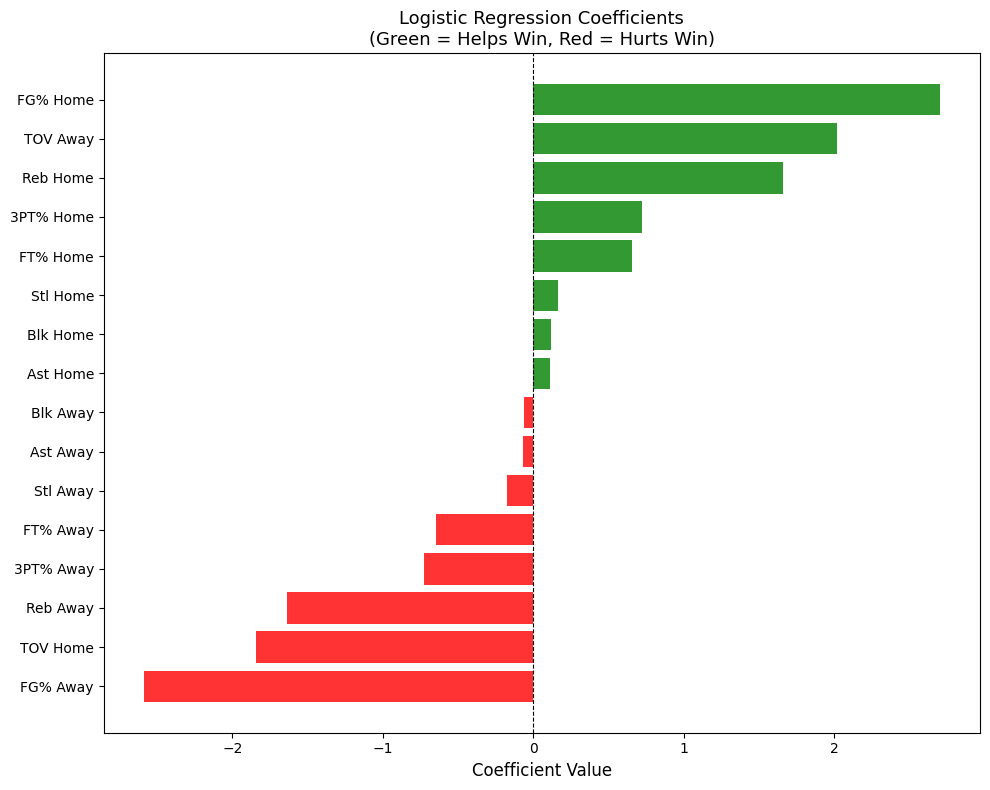

In [37]:
# Feature importance from logistic regression coefficients
feature_names = ['FG% Home', '3PT% Home', 'FT% Home', 'Ast Home',
                 'Reb Home', 'TOV Home', 'Stl Home', 'Blk Home',
                 'FG% Away', '3PT% Away', 'FT% Away', 'Reb Away',
                 'Ast Away', 'TOV Away', 'Stl Away', 'Blk Away']

coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=True)

colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Logistic Regression Coefficients\n(Green = Helps Win, Red = Hurts Win)', fontsize=13)
plt.tight_layout()
plt.savefig('../visuals/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance Analysis
### Chart Explanation
The chart shows the coefficient values tied to each feature. The value of the coefficients determines how important that feature was in predicting a win or a loss. The green values show which features help predict a win. For example, FG% Home was the biggest driver of predicting wins (home teams with high fg% win more). On the other hand, the red values show the features that when that feature is increased the team is more likely to lose. For example, FG% Away shows us that when the away team shoots well then the home team loses.

### Important Positive and Negative Values
The top three positive values are FG% Home, TOV Away, and Reb Home. This means that when the home team has a high field goal percentage and a high rebound count they tend to win. Also, when the away team has a high turnover count the home team tends to win.

The top three negative values are FG% Away, TOV Home, and Reb Away. This means that when the away team has a high field goal percentage and high rebound count the home team tends to lose. Also, when the home team has a high turnover count they tend to lose.

These findings line up with what we concluded throughout this report. The only surprising finding is how much turnovers actually affect wins and losses.

### Turnovers
Earlier in this report I concluded that turnovers didn't play a role in determining wins and losses. That was due to the home and away teams having similar average turnovers per game. Now, this final graph showed that turnovers actually play a major role in predicting wins and losses. That means that our model depended on home turnover counts and away turnover counts quite a bit when trying to predict a win or loss. 

The raw average masked this effect because both home turnovers and away turnovers were happening simultaneously. They were essentially cancelling each other out and our simple comparison was not picking up on their true effect.

### Original Research Question "What Actually Wins NBA Games?"
When I started this project the question above was what I wanted to answer. I was curious if there were certain stats that stood out when determining wins and losses. Now, after all our analysis I can confidently confirm this is the case. 

I found that Home/Away FG%, Home/Away TOV, and Home/Away Reb are the biggest drivers of prediction. These features outweigh all others when determining a win and loss.

The most unexpected result was that turnovers, which appeared irrelevant in early analysis, emerged as the second and third most important features in the final model.

### Project Conclusion
Throughout this project I set out to answer one question: what actually wins NBA games? After analyzing 47,502 regular season games from 1980 to present, the data gave a clear answer. Shooting efficiency (FG%) is the single biggest driver of winning, followed by turnover management, and rebounding. A logistic regression model trained on these stats predicted game outcomes with 91.5% accuracy, which is well above the 60.6% baseline of simply guessing the home team wins every time.

The most surprising finding was turnovers. Early in the analysis they appeared to have almost no impact. The model revealed they matter enormously. Although, they only matter when you separate home turnovers from away turnovers. Simple averages masked this entirely.

If I were to extend this project I would apply this same analysis to playoff data to see if the same factors predict postseason success, and I would build a pre-game prediction model using season averages rather than in-game stats.